Go to cd salil <br> Activate the torchenv:<br> source Envs/torchenv/bin/activate
<br> Then go to cd FirstRepository

In [3]:
import sys
import torch
print(f"Environment Path: {sys.executable}")
print(f"PyTorch Version: {torch.__version__}")


Environment Path: /home/s0shar47/scratch/salil/Envs/torchenv/bin/python
PyTorch Version: 2.12.0+cu130


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Transformations: Convert images to Tensors and Normalize (0-1)
transform = transforms.Compose([transforms.ToTensor()])

# 2. Download and Load Data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [7]:
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 100) # Hidden Layer
        self.fc2 = nn.Linear(100, 10)      # Output Layer

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        # Note: We don't use Sigmoid/Softmax here because 
        # CrossEntropyLoss handles it automatically for better stability.
        x = self.fc2(x)
        return x

model = MNISTModel()


In [8]:
criterion = nn.CrossEntropyLoss() #crossentropy
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [9]:
epochs = 10

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward pass and optimization
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()        # Calculate new gradients
        optimizer.step()       # Update weights
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/10 - Loss: 0.3053
Epoch 2/10 - Loss: 0.1362
Epoch 3/10 - Loss: 0.0962
Epoch 4/10 - Loss: 0.0728
Epoch 5/10 - Loss: 0.0580
Epoch 6/10 - Loss: 0.0482
Epoch 7/10 - Loss: 0.0390
Epoch 8/10 - Loss: 0.0325
Epoch 9/10 - Loss: 0.0268
Epoch 10/10 - Loss: 0.0230


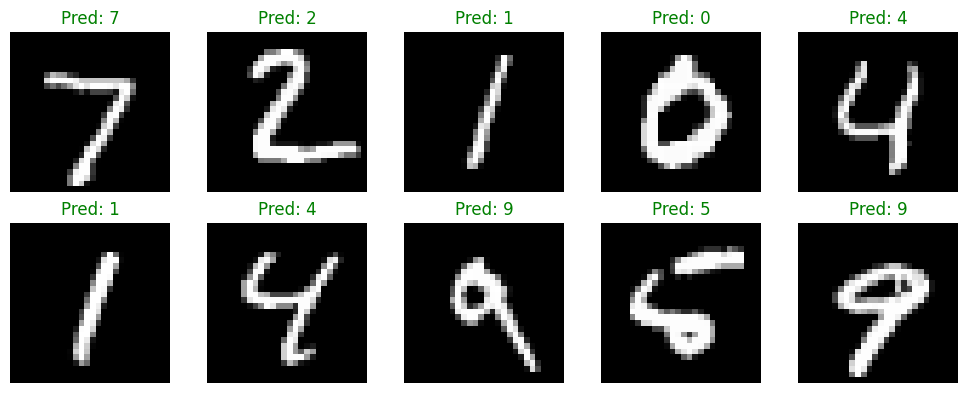

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set model to evaluation mode
model.eval()

# 2. Get a batch of test images
images, labels = next(iter(test_loader))

# 3. Perform prediction without tracking gradients
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# 4. Visualize the results
plt.figure(figsize=(10, 4))
for i in range(10):  # Show first 10 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f"Pred: {predicted[i].item()}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [11]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on 10,000 test images: {100 * correct / total:.2f}%')


Accuracy on 10,000 test images: 97.73%
